# Lung Cancer Risk Prediction
Dataset: Lung Cancer Survey Dataset  
Target: `LUNG_CANCER` (YES→1, NO→0)

## 1 · Imports & Data Load

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve)
from xgboost import XGBClassifier
import joblib, json

df = pd.read_csv("../data/lung_cancer.csv")
df.columns = df.columns.str.strip()
df['target'] = (df['LUNG_CANCER'] == 'YES').astype(int)
print(df.shape)
print("Class balance:", df['target'].value_counts().to_dict())
df.head()

(309, 17)
Class balance: {1: 270, 0: 39}


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER,target
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES,1
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES,1
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO,0
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO,0
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO,0


In [2]:
print("Original encoding (2=yes, 1=no) for first feature:")
print(df['SMOKING'].value_counts())
print("Missing values:", df.isnull().sum().sum())

Original encoding (2=yes, 1=no) for first feature:
SMOKING
2    174
1    135
Name: count, dtype: int64
Missing values: 0


## 3 · Feature Engineering & Field Mapping



In [3]:
FEAT_RAW   = ['SMOKING','YELLOW_FINGERS','ANXIETY','CHRONIC DISEASE','WHEEZING','CHEST PAIN']
FEAT_CLEAN = ['smoking','yellow_fingers','anxiety','chronic_disease','wheezing','chest_pain']

for c in FEAT_RAW:
    df[c] = (df[c] == 2).astype(int)   # 2=yes → 1, 1=no → 0

X = df[FEAT_RAW].copy()
X.columns = FEAT_CLEAN
y = df['target']
print("Recoded sample:")
print(X.head())

Recoded sample:
   smoking  yellow_fingers  anxiety  chronic_disease  wheezing  chest_pain
0        0               1        1                0         1           1
1        1               0        0                1         0           1
2        0               0        0                0         1           1
3        1               1        1                0         0           1
4        0               1        0                0         1           0


## 4–5 · Preprocessing & Split 

In [4]:
def make_pipe(clf):
    return Pipeline([('imputer', SimpleImputer(strategy='median')),
                     ('scaler',  StandardScaler()), ('clf', clf)])

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (247, 6), Test: (62, 6)


## 6 · Model Training & Comparison

In [6]:
candidates = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost':            XGBClassifier(n_estimators=200, random_state=42,
                                        eval_metric='logloss', verbosity=0),
}
results = {}; pipes = {}
for name, clf in candidates.items():
    p = make_pipe(clf); p.fit(X_train, y_train)
    yp = p.predict(X_test); ypr = p.predict_proba(X_test)[:,1]
    results[name] = {'accuracy': round(accuracy_score(y_test,yp),4),
                     'precision': round(precision_score(y_test,yp),4),
                     'recall': round(recall_score(y_test,yp),4),
                     'f1': round(f1_score(y_test,yp),4),
                     'roc_auc': round(roc_auc_score(y_test,ypr),4)}
    pipes[name] = p
pd.DataFrame(results).T.sort_values('roc_auc', ascending=False)

,accuracy,precision,recall,f1,roc_auc
RandomForest,0.8387,0.8929,0.9259,0.9091,0.9120
XGBoost,0.8710,0.9107,0.9444,0.9273,0.8889
LogisticRegression,0.8548,0.8689,0.9815,0.9217,0.8171


## 7 · Evaluation

Best: RandomForest


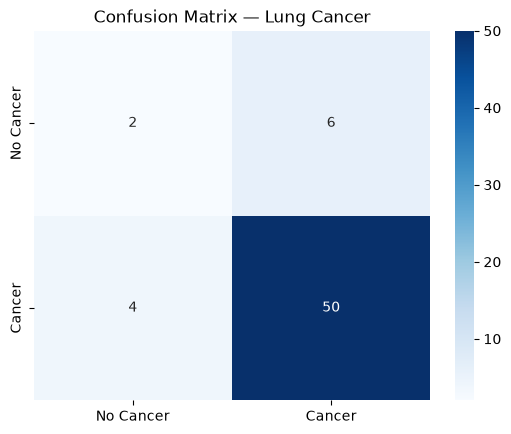

              precision    recall  f1-score   support

   No Cancer       0.33      0.25      0.29         8
      Cancer       0.89      0.93      0.91        54

    accuracy                           0.84        62
   macro avg       0.61      0.59      0.60        62
weighted avg       0.82      0.84      0.83        62



In [7]:
best_name = max(results, key=lambda k: results[k]['roc_auc'])
best = pipes[best_name]; print(f"Best: {best_name}")
y_pred = best.predict(X_test); y_proba = best.predict_proba(X_test)[:,1]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Cancer','Cancer'], yticklabels=['No Cancer','Cancer'])
plt.title('Confusion Matrix — Lung Cancer'); plt.show()
print(classification_report(y_test, y_pred, target_names=['No Cancer','Cancer']))

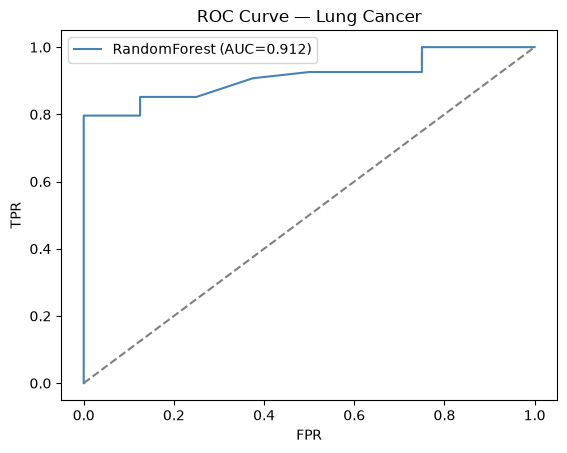

In [8]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'{best_name} (AUC={results[best_name]["roc_auc"]})', color='steelblue')
plt.plot([0,1],[0,1],'--',color='grey'); plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curve — Lung Cancer'); plt.legend(); plt.show()

## 8 · Save

In [10]:
joblib.dump(best, '../models/lung_cancer_model.joblib')
metrics = {**results[best_name], 'model': best_name,
           'features': FEAT_CLEAN, 'test_size': 0.2, 'random_state': 42}
with open('../metrics/lung_cancer_metrics.json','w') as f: json.dump(metrics,f,indent=2)